The European "Hot Girl Walk" (HGW) Index

In [48]:
import pandas as pd

# The Numbeo URL for 2026 Safety
url = "https://www.numbeo.com/quality-of-life/region_rankings.jsp?title=2026&displayColumn=2&region=150"

# read_html
safety_tables = pd.read_html(url)
df_safety = safety_tables[1] # Numbeo often has a header table at [0], so we use [1]

# Clean it up to keep only 'City' and 'Safety Index'
df_safety = df_safety[['City', 'Safety Index']]
print(df_safety.head(20))

                                 City  Safety Index
0   The Hague (Den Haag), Netherlands          80.0
1                Utrecht, Netherlands          79.0
2              Eindhoven, Netherlands          79.1
3              Groningen, Netherlands          78.4
4              Rotterdam, Netherlands          74.0
5              Luxembourg, Luxembourg          72.1
6                     Vienna, Austria          71.6
7              Amsterdam, Netherlands          74.3
8                       Gent, Belgium          76.2
9                  Nuremberg, Germany          70.0
10                Copenhagen, Denmark          74.3
11                    Munich, Germany          78.9
12                    Valencia, Spain          65.3
13                 Gothenburg, Sweden          54.2
14                 Basel, Switzerland          68.6
15                     Bergen, Norway          76.2
16                 Frankfurt, Germany          55.5
17                  Stavanger, Norway          74.9
18          

In [49]:
print(df_safety.shape) 
# This keeps only the part BEFORE the comma
df_safety['City'] = df_safety['City'].str.split(',').str[0]
print(df_safety.head(25))

(113, 2)
                    City  Safety Index
0   The Hague (Den Haag)          80.0
1                Utrecht          79.0
2              Eindhoven          79.1
3              Groningen          78.4
4              Rotterdam          74.0
5             Luxembourg          72.1
6                 Vienna          71.6
7              Amsterdam          74.3
8                   Gent          76.2
9              Nuremberg          70.0
10            Copenhagen          74.3
11                Munich          78.9
12              Valencia          65.3
13            Gothenburg          54.2
14                 Basel          68.6
15                Bergen          76.2
16             Frankfurt          55.5
17             Stavanger          74.9
18                  Bern          74.1
19                 Plzen          75.5
20             Stuttgart          70.0
21            Dusseldorf          67.3
22              Helsinki          74.6
23                Zurich          76.6
24              

In [50]:
# Check for missing values in each column 
print(df_safety.isnull().sum())

City            0
Safety Index    0
dtype: int64


There is no null valus in the data set 

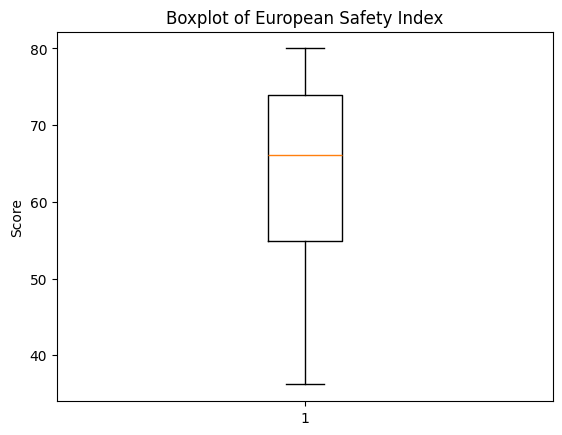

In [51]:
import matplotlib.pyplot as plt
plt.boxplot(df_safety['Safety Index'])
plt.title('Boxplot of European Safety Index')
plt.ylabel('Score')
plt.show()

The boxplot shows that the Safety Index contains no extreme outliers.
- The median safety score sits around 66.
- The Interquartile Range Most cities are between 55 and 74.

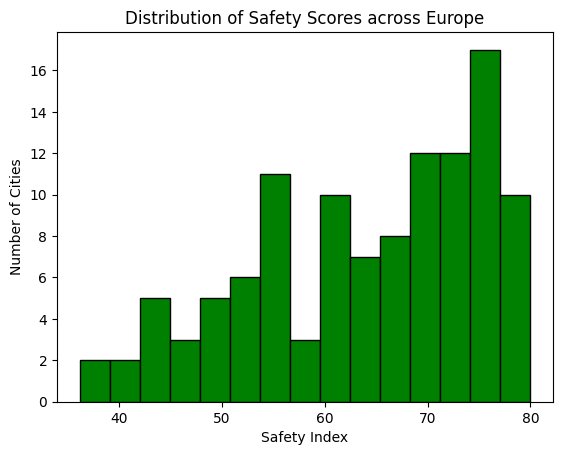

In [52]:
plt.hist(df_safety['Safety Index'], bins=15, color='green', edgecolor='black')
plt.title('Distribution of Safety Scores across Europe')
plt.xlabel('Safety Index')
plt.ylabel('Number of Cities')
plt.show()

Histogram shows the Frequency and Skewness.

- Left-Skewed Distribution: You can see that the highest frequency are on the right side of the chart between 70 and 80.

- The Safety Peak: The most common safety score in Europe is between 74 and 77, with 17 cities falling into this bracket.

- The Safety Gap: There is a small dip in the middle around 58, suggesting a divide between cities with a high safety rating and those with moderate safety concerns.

Enviroment data 

In [53]:
import pandas as pd

#  Load the data
df_green = pd.read_csv(
    'green-area-per_capita-square-meters-per-capita.csv', 
    skiprows=4, 
    encoding='utf-8-sig',
    engine='python',
    on_bad_lines='skip'
)

#  remame columns 
# take the first column [0] and the last column [-1]
df_green.rename(columns={df_green.columns[0]: 'City', df_green.columns[-1]: 'Green_area'}, inplace=True)

df_hgw_green = df_green[['City', 'Green_area']].copy()

df_hgw_green['Green_area'] = pd.to_numeric(df_hgw_green['Green_area'], errors='coerce')

# Drop the NaN rows the '..' ones
df_hgw_green = df_hgw_green.dropna(subset=['Green_area'])

# Clean City names
df_hgw_green['City'] = df_hgw_green['City'].str.strip()

print(df_hgw_green.head(20))

                      City  Green_area
0                   Sydney      224.94
1                Melbourne      152.17
2                 Brisbane     1158.07
3                    Perth       78.14
4                 Adelaide       37.14
5   Gold Coast-Tweed Heads      108.62
7                   Vienna      620.16
8                     Graz      551.67
9                     Linz     1043.67
11                Brussels      738.44
12                 Antwerp      331.43
13                   Ghent      429.10
14                   Liege      357.40
16               Vancouver      244.49
17                Montreal     3130.35
18                 Toronto     9016.11
19                Edmonton     6261.38
20                 Calgary     1492.95
21                Winnipeg     3741.07
22                  Quebec     1376.82


In [54]:
# Ensure both City columns are exactly the same type and stripped of spaces
df_safety['City'] = df_safety['City'].astype(str).str.strip()
df_hgw_green['City'] = df_hgw_green['City'].astype(str).str.strip()

# Inner Join
# This keeps only cities that appear in both
df_europe_master = pd.merge(df_safety, df_hgw_green, on='City', how='inner')

print(f"European cities with both Safety and Greenery data: {len(df_europe_master)}")

print(df_europe_master[['City', 'Safety Index', 'Green_area']].head(20))

European cities with both Safety and Greenery data: 55
          City  Safety Index  Green_area
0      Utrecht          79.0      168.08
1    Eindhoven          79.1      579.15
2    Rotterdam          74.0      106.68
3       Vienna          71.6      620.16
4    Amsterdam          74.3      508.09
5    Nuremberg          70.0      792.52
6   Copenhagen          74.3      761.83
7       Munich          78.9     1601.13
8     Valencia          65.3       23.82
9   Gothenburg          54.2      262.53
10       Basel          68.6      286.57
11   Frankfurt          55.5      253.74
12   Stuttgart          70.0      346.67
13    Helsinki          74.6      115.92
14      Zurich          76.6      334.87
15      Geneva          70.6      551.46
16     Hamburg          60.3     2750.62
17   Edinburgh          69.6      156.27
18   Liverpool          51.5       57.96
19     Glasgow          54.8      100.03


In [55]:
import statsmodels.api as sm
# x1 = Green_area, y = Safety Index
X = df_europe_master['Green_area']
y = df_europe_master['Safety Index']

# Add constant for the intercept
X = sm.add_constant(X)

# Fit the OLS (Ordinary Least Squares) model
model = sm.OLS(y, X).fit()

# This summary the R-squared and P-values 
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Safety Index   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.880
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.176
Time:                        19:12:12   Log-Likelihood:                -214.67
No. Observations:                  55   AIC:                             433.3
Df Residuals:                      53   BIC:                             437.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         60.3689      2.170     27.825      0.0

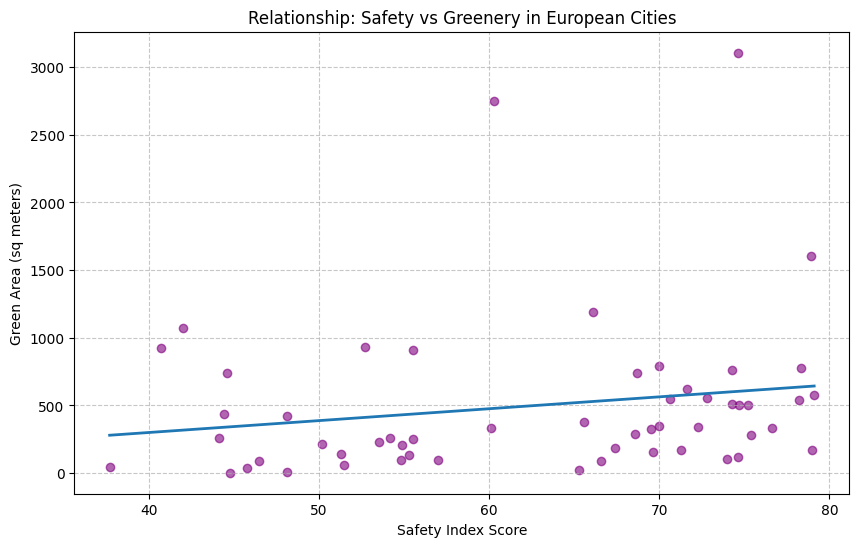

In [56]:
from matplotlib import pyplot as plt
import numpy as np

x = df_europe_master['Safety Index']
y = df_europe_master['Green_area']

plt.figure(figsize=(10, 6))
plt.title("Relationship: Safety vs Greenery in European Cities")
plt.xlabel("Safety Index Score")
plt.ylabel("Green Area (sq meters)")

# Create the scatter plot
plt.scatter(x, y, color='purple', alpha=0.6,)

# Calculate and plot the "Line of Best Fit" (Linear Regression Line)
# np.polyfit(x, y, 1) calculates the slope and intercept
stats = np.polyfit(x, y, 1)
line_function = np.poly1d(stats)
plt.plot(np.unique(x), line_function(np.unique(x)), linewidth=2)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [57]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(x, y)
print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.3f}")


Correlation: 0.185
P-value: 0.176


In Europe, just because a city is safe doesn't mean it’s green, and vice versa.
A Pearson correlation of 0.185 (p=0.176) shows that Safety and Greenery are statistically independent and non-redundant.

In [ ]:
# Load UNESCO data 
df_unesco = pd.read_excel('whc-sites-2025.xls')

print(df_unesco.columns)
df_unesco.head()

# Create a count of sites per country (using the 'states_name_en' column)
unesco_counts = df_unesco['states_name_en'].value_counts().reset_index()
unesco_counts.columns = ['Country', 'Heritage_Site_Count']

# Strip any whitespace from 'Country' to ensure a clean merge
unesco_counts['Country'] = unesco_counts['Country'].str.strip()

Index(['unique_number', 'id_no', 'rev_bis', 'name_en', 'name_fr', 'name_es',
       'name_ru', 'name_ar', 'name_zh', 'short_description_en',
       'short_description_fr', 'short_description_es', 'short_description_ru',
       'short_description_ar', 'short_description_zh', 'justification_en',
       'justification_fr', 'date_inscribed', 'secondary_dates', 'danger',
       'date_end', 'danger_list', 'longitude', 'latitude', 'area_hectares',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'N7', 'N8', 'N9', 'N10',
       'criteria_txt', 'category', 'category_short', 'states_name_en',
       'states_name_fr', 'states_name_es', 'states_name_ru', 'states_name_ar',
       'states_name_zh', 'region_en', 'region_fr', 'iso_code', 'udnp_code',
       'transboundary'],
      dtype='str')


In [ ]:
# Count how many sites each country has
unesco_counts = df_unesco['states_name_en'].value_counts().reset_index()

unesco_counts.columns = ['Country', 'Heritage_Count']

# Clean 'Country' strings 
unesco_counts['Country'] = unesco_counts['Country'].str.split(',').str[0].str.strip()

# Consolidate counts if the split created duplicates
unesco_counts = unesco_counts.groupby('Country')['Heritage_Count'].sum().reset_index()

print(unesco_counts.head(10))

               Country  Heritage_Count
0          Afghanistan               2
1              Albania               4
2              Algeria               7
3              Andorra               1
4               Angola               1
5  Antigua and Barbuda               1
6            Argentina              12
7              Armenia               3
8            Australia              21
9              Austria              11


In [ ]:
from geopy.geocoders import Nominatim
import pandas as pd
import time

#  Initialize the Geocoder
geolocator = Nominatim(user_agent="hgw_index_full_api_v4")

def get_country_api(city):
    try:
        # API Rate Limits (1 request per second)
        time.sleep(1.1) 
        location = geolocator.geocode(city, language='en', addressdetails=True)
        
        if location and 'address' in location.raw:
            return location.raw['address'].get('country', None)
        return None
    except Exception as e:
        print(f"Error for {city}: {e}")
        return None

#  Apply the API to the entire 'City' column
print(f"Fetching countries for {len(df_europe_master)} cities via API. Please wait...")
df_europe_master['Country'] = df_europe_master['City'].apply(get_country_api)

# Handle UNESCO Naming Standards Even with the API, UNESCO requires these specific formal names for a successful merge
unesco_names = {
    'United Kingdom': 'United Kingdom of Great Britain and Northern Ireland',
    'Czech Republic': 'Czechia',
    'Czech Rep.': 'Czechia'
}
df_europe_master['Country'] = df_europe_master['Country'].replace(unesco_names).str.strip()

# Check
print(df_europe_master[['City', 'Country']].head(15))


Fetching countries for 55 cities via API. Please wait...
          City      Country
0      Utrecht  Netherlands
1    Eindhoven  Netherlands
2    Rotterdam  Netherlands
3       Vienna      Austria
4    Amsterdam  Netherlands
5    Nuremberg      Germany
6   Copenhagen      Denmark
7       Munich      Germany
8     Valencia        Spain
9   Gothenburg       Sweden
10       Basel  Switzerland
11   Frankfurt      Germany
12   Stuttgart      Germany
13    Helsinki      Finland
14      Zurich  Switzerland


In [ ]:
# Clean the UNESCO dataset one last time to ensure matching
unesco_counts['Country'] = unesco_counts['Country'].str.strip()

#  Merge Pillar 3 (Aesthetics) into master dataframe
# We use a Left Join so we don't lose any of your 55 cities
df_europe_master = pd.merge(df_europe_master, unesco_counts, on='Country', how='left')

# Fill cities in countries with 0 UNESCO sites with 0 (instead of NaN)
df_europe_master['Heritage_Count'] = df_europe_master['Heritage_Count'].fillna(0)

# Check
print(f"Current table: {len(df_europe_master)} cities")
print(df_europe_master[['City', 'Country', 'Safety Index', 'Green_area', 'Heritage_Count']].head(20))

Current table: 55 cities
          City                                            Country  \
0      Utrecht                                        Netherlands   
1    Eindhoven                                        Netherlands   
2    Rotterdam                                        Netherlands   
3       Vienna                                            Austria   
4    Amsterdam                                        Netherlands   
5    Nuremberg                                            Germany   
6   Copenhagen                                            Denmark   
7       Munich                                            Germany   
8     Valencia                                              Spain   
9   Gothenburg                                             Sweden   
10       Basel                                        Switzerland   
11   Frankfurt                                            Germany   
12   Stuttgart                                            Germany   
13    Hel

In [ ]:
import statsmodels.api as sm

X = df_europe_master[['Green_area', 'Heritage_Count']]

y = df_europe_master['Safety Index']

# Add a constant represents the Safety Index if Greenery and Heritage were both zero
X = sm.add_constant(X)

# Fit the Multiple OLS Model
model = sm.OLS(y, X).fit()

# Display the results
print("HGW Index Multiple Regression Analysis")
print(model.summary())

--- HGW Index Multiple Regression Analysis ---
                            OLS Regression Results                            
Dep. Variable:           Safety Index   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     13.18
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           2.34e-05
Time:                        21:18:26   Log-Likelihood:                -204.35
No. Observations:                  55   AIC:                             414.7
Df Residuals:                      52   BIC:                             420.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

The number of UNESCO sites in a country has a massive link to the Safety Index of its cities.
The coefficient is -0.3489. This suggests that in this specific 55-city, as the national Heritage Count goes up, the Safety Index slightly decreases.

Highly "aesthetic" or tourist-heavy countries like Italy or France might face higher petty crime (like pick pocketing) rates in their major cities, impacting the Safety Index.

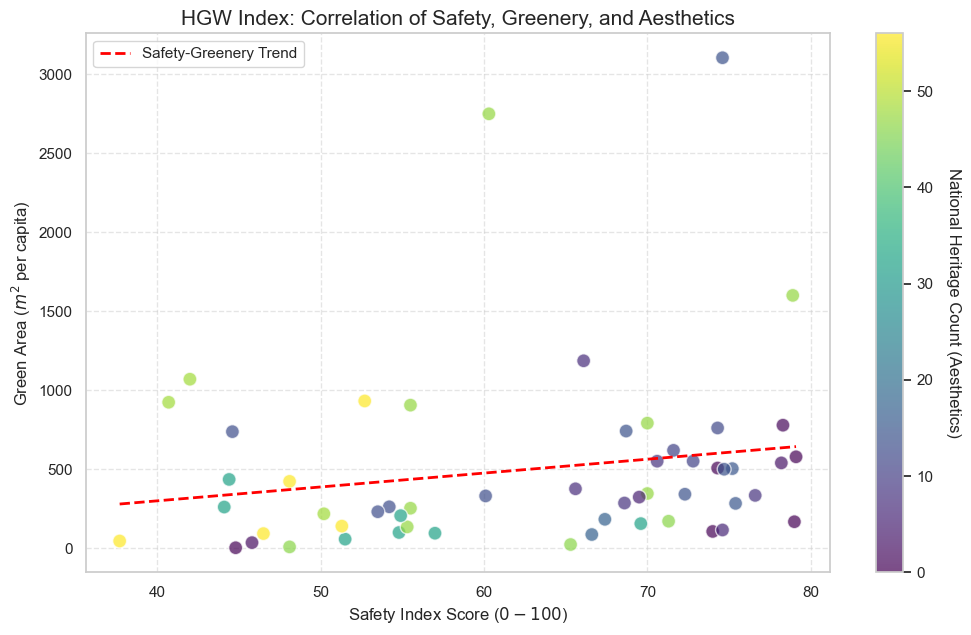

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

# Define the variables
x = df_europe_master['Safety Index']
y = df_europe_master['Green_area']
z = df_europe_master['Heritage_Count'] 

plt.figure(figsize=(12, 7))

# Updated Scatter Plot

scatter = plt.scatter(x, y, c=z, cmap='viridis', s=100, alpha=0.7, edgecolors='white')

# Colorbar to explain what the colors mean
cbar = plt.colorbar(scatter)
cbar.set_label('National Heritage Count (Aesthetics)', rotation=270, labelpad=20)

#  Line of Best Fit (Linear Regression for X and Y)
stats = np.polyfit(x, y, 1)
line_function = np.poly1d(stats)
plt.plot(np.unique(x), line_function(np.unique(x)), color='red', linestyle='--', linewidth=2, label='Safety-Greenery Trend')

# Labels and Title with LaTeX formatting
plt.title("HGW Index: Correlation of Safety, Greenery, and Aesthetics", fontsize=15)
plt.xlabel("Safety Index Score ($0-100$)", fontsize=12)
plt.ylabel("Green Area ($m^2$ per capita)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()
plt.close()

The red dashed line has a positive slope Thisconfirms that as Safety increases, Green Area tends to increase as well.
The yellow dots (high heritage countries) are scattered across the safety spectrum, but many cluster between 40−60 safety. This explains why the heritage coefficient in the regression was negative higher heritage density often correlates with slightly lower safety scores.